# Projet Final - Forage de données (8INF436)
**Sujet :** Prédire le score de crédit d'un client bancaire  
**Groupe :** Frantxa Cabrejos, Loup-Djabril Le Bivic, Nathan Razafindratsima  
**Dataset :** Credit Score Classification - Kaggle (100 000 observations)  
**Problème :** Classification multi-classes : Good / Standard / Poor

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC                         
from sklearn.calibration import CalibratedClassifierCV 

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('imports ok')

imports ok


## 1. Chargement du dataset

Source : https://www.kaggle.com/datasets/parisrohan/credit-score-classification  
Télécharger `train.csv` et le placer dans le dossier `data/`.

In [2]:
csv_files = glob.glob('data/train.csv') + glob.glob('../data/train.csv') + glob.glob('train.csv')
print('fichiers trouvés :', csv_files)

df_raw = pd.read_csv(csv_files[0], low_memory=False)
print(f'{df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes')

fichiers trouvés : ['data/train.csv']
100000 lignes, 28 colonnes


## 2. Exploration du dataset

In [3]:
df_raw.head(5)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [4]:
# types et valeurs non-nulles par colonne
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [5]:
# description
df_raw.describe(include='all')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN


### 2.1 Analyse des valeurs manquantes

In [6]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2).sort_values(ascending=False)
print('colonnes avec valeurs manquantes :')
print(missing_pct[missing_pct > 0])

colonnes avec valeurs manquantes :
Monthly_Inhand_Salary      15.00
Type_of_Loan               11.41
Name                        9.98
Credit_History_Age          9.03
Num_of_Delayed_Payment      7.00
Amount_invested_monthly     4.48
Num_Credit_Inquiries        1.96
Monthly_Balance             1.20
dtype: float64


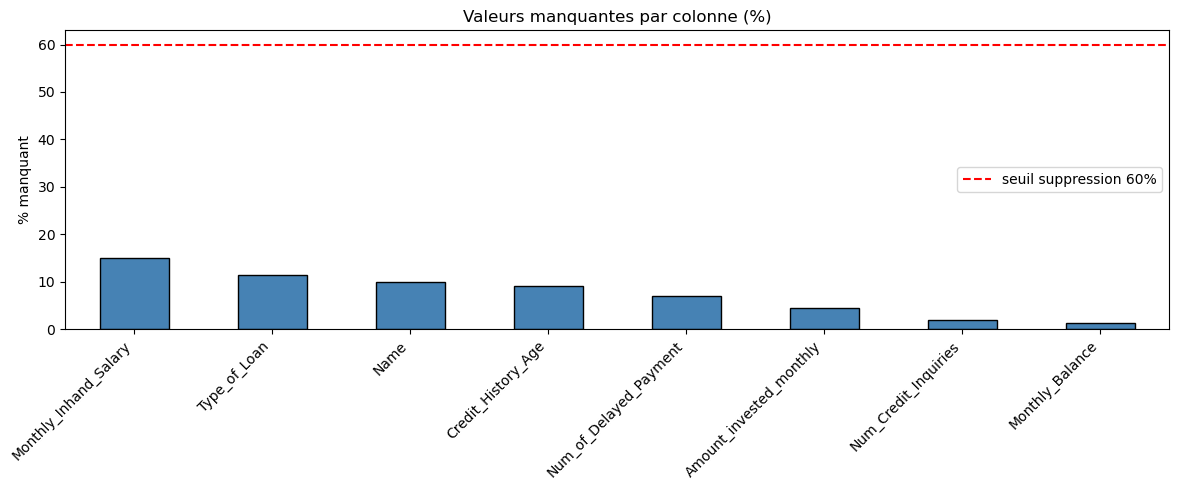

In [7]:
manquants = missing_pct[missing_pct > 0]
if len(manquants) > 0:
    plt.figure(figsize=(12, 5))
    manquants.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.axhline(60, color='red', linestyle='--', label='seuil suppression 60%')
    plt.title('Valeurs manquantes par colonne (%)')
    plt.ylabel('% manquant')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 2.2 Distribution de la variable cible

3 classes : Good, Standard, Poor.
SMOTE pour déséquilibré

distribution variable cible :
Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64


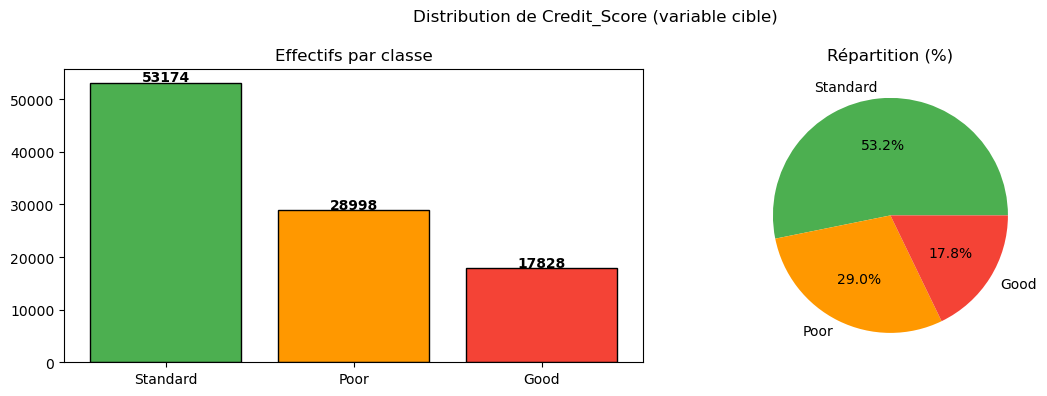

ratio déséquilibre max/min : 3.0x


In [8]:
TARGET_COL = 'Credit_Score'
print('distribution variable cible :')
print(df_raw[TARGET_COL].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_raw[TARGET_COL].value_counts()
colors = ['#4caf50', '#ff9800', '#f44336']

bars = axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='black')
axes[0].set_title('Effectifs par classe')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors[:len(counts)], autopct='%1.1f%%')
axes[1].set_title('Répartition (%)')

plt.suptitle('Distribution de Credit_Score (variable cible)', fontsize=12)
plt.tight_layout()
plt.show()

ratio_dsq = counts.max() / counts.min()
print(f'ratio déséquilibre max/min : {ratio_dsq:.1f}x')

### 2.3 Exemples de données corrompues

In [9]:
# aperçu des valeurs dans les premières colonnes object
for col in df_raw.select_dtypes(include='object').columns[:8]:
    uniques = df_raw[col].dropna().unique()[:5]
    print(f'{col}: {uniques}')

ID: ['0x1602' '0x1603' '0x1604' '0x1605' '0x1606']
Customer_ID: ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' 'CUS_0xb891' 'CUS_0x1cdb']
Month: ['January' 'February' 'March' 'April' 'May']
Name: ['Aaron Maashoh' 'Rick Rothackerj' 'Langep' 'Jasond' 'Deepaa']
Age: ['23' '-500' '28_' '28' '34']
SSN: ['821-00-0265' '#F%$D@*&8' '004-07-5839' '486-85-3974' '072-31-6145']
Occupation: ['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur']
Annual_Income: ['19114.12' '34847.84' '34847.84_' '143162.64' '30689.89']


## 3. Préparation des données

1. Suppression des colonnes inutiles
2. Nettoyage des valeurs corrompues
3. Encodage des variables catégorielles
4. Imputation des valeurs manquantes 
5. Normalisation min-max
6. Split train/test 80/20 stratifié
7. Suréchantillonnage SMOTE sur le train

In [10]:
df = df_raw.copy()

# 1. supprimer les colonnes identifiants : pas de valeur discriminante pour la classification
cols_id = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
cols_drop = [c for c in cols_id if c in df.columns]
df.drop(columns=cols_drop, inplace=True)
print('colonnes supprimées (identifiants) :', cols_drop)
print('shape :', df.shape)

colonnes supprimées (identifiants) : ['ID', 'Customer_ID', 'Name', 'SSN', 'Month']
shape : (100000, 23)


In [11]:
# nettoyage : colonnes numériques stockées en string avec caractères parasites

cols_num_str = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
    'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_num_str:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('[^0-9.-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# suppression des valeurs aberrantes
if 'Age' in df.columns:
    df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan
if 'Annual_Income' in df.columns:
    df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan

print('nettoyage numérique ok')
# print(df.dtypes) 

nettoyage numérique ok


In [12]:
# séparation X / y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'X : {X.shape}')
print(f'colonnes numériques ({len(num_cols)}) : {num_cols}')
print(f'colonnes catégorielles ({len(cat_cols)}) : {cat_cols}')

X : (100000, 22)
colonnes numériques (17) : ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
colonnes catégorielles (5) : ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [13]:
# encodage de la variable cible
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print('classes :', list(zip(le_target.classes_, range(len(le_target.classes_)))))

classes : [('Good', 0), ('Poor', 1), ('Standard', 2)]


In [14]:
# encodage des variables catégorielles avec LabelEncoder
# on remplit les NaN par 'inconnu' avant encodage pour éviter une erreur
X_enc = X.copy()
encoders = {} 
for col in cat_cols:
    X_enc[col] = X_enc[col].fillna('inconnu')
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    encoders[col] = le

print(f'encodage ok ({len(cat_cols)} colonnes catégorielles)')

encodage ok (5 colonnes catégorielles)


In [15]:
# imputation par la médiane (robuste aux valeurs extrêmes)
print('NaN avant imputation :', X_enc.isnull().sum().sum())

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X_enc), columns=X_enc.columns)

print('NaN après imputation :', X_imp.isnull().sum().sum())

NaN avant imputation : 49251
NaN après imputation : 0


In [16]:
# normalisation min-max entre 0 et 1
# nécessaire pour le SVM
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns)

print('normalisation min-max ok')
print(f'min global : {X_scaled.min().min():.3f} | max global : {X_scaled.max().max():.3f}')

normalisation min-max ok
min global : 0.000 | max global : 1.000


In [17]:
# split train/test 80/20 stratifié
# stratifié : chaque partie garde la même proportion des 3 classes
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)
print(f'train : {X_train.shape[0]} lignes | test : {X_test.shape[0]} lignes')

train : 80000 lignes | test : 20000 lignes


In [18]:
# SMOTE : suréchantillonnage sur le train uniquement
# génère des exemples synthétiques pour équilibrer les classes
# jamais appliqué sur le test

vals, cnts = np.unique(y_train, return_counts=True)
ratio_dsq = cnts.max() / cnts.min()
print(f'ratio déséquilibre train : {ratio_dsq:.1f}x')

if ratio_dsq > 1.5:
    k = min(5, cnts.min() - 1)
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f'train avant SMOTE : {len(X_train)} | après SMOTE : {len(X_train_res)}')
else:
    X_train_res, y_train_res = X_train, y_train
    print('classes déjà équilibrées, SMOTE non nécessaire')

ratio déséquilibre train : 3.0x
train avant SMOTE : 80000 | après SMOTE : 127617


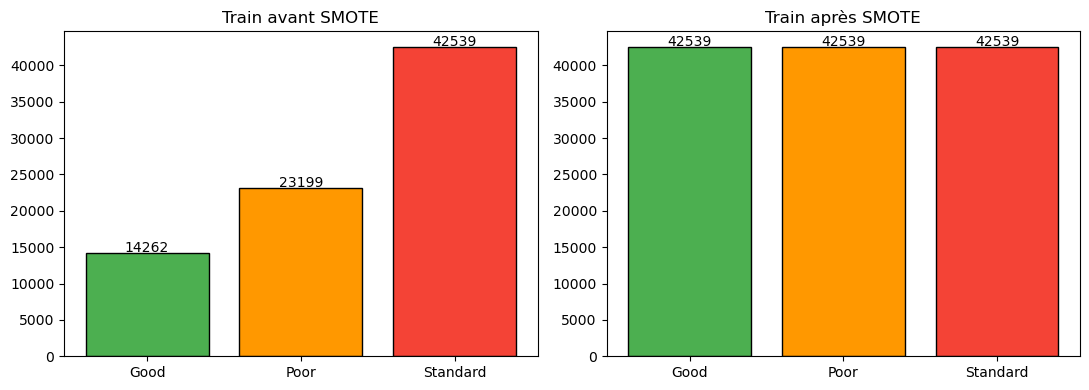

In [19]:
# visualisation avant / après SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4caf50', '#ff9800', '#f44336']

for ax, y_data, title in [
    (axes[0], y_train, 'Train avant SMOTE'),
    (axes[1], y_train_res, 'Train après SMOTE')
]:
    v, c = np.unique(y_data, return_counts=True)
    labs = [le_target.classes_[i] for i in v]
    ax.bar(labs, c, color=colors[:len(v)], edgecolor='black')
    ax.set_title(title)
    for i, val in enumerate(c):
        ax.text(i, val + 100, str(val), ha='center')

plt.tight_layout()
plt.show()

## 4. Réduction de dimension

Deux approches complémentaires du Chapitre 4 du cours :

**Feature Selection** : importance via random forest, 15 meilleures features pour random forest et Gradient Boosting.

**PCA** : StandardScaler + composantes à 95 % de variance pour SVM.

In [20]:
# Feature Selection importance des features, on garde les 15 meilleures

rf_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    max_features=15
)
rf_selector.fit(X_train_res, y_train_res)

cols_sel = X_train_res.columns[rf_selector.get_support()].tolist()
print(f'{len(cols_sel)} dimensions sélectionnées : {cols_sel}')

9 dimensions sélectionnées : ['Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt']


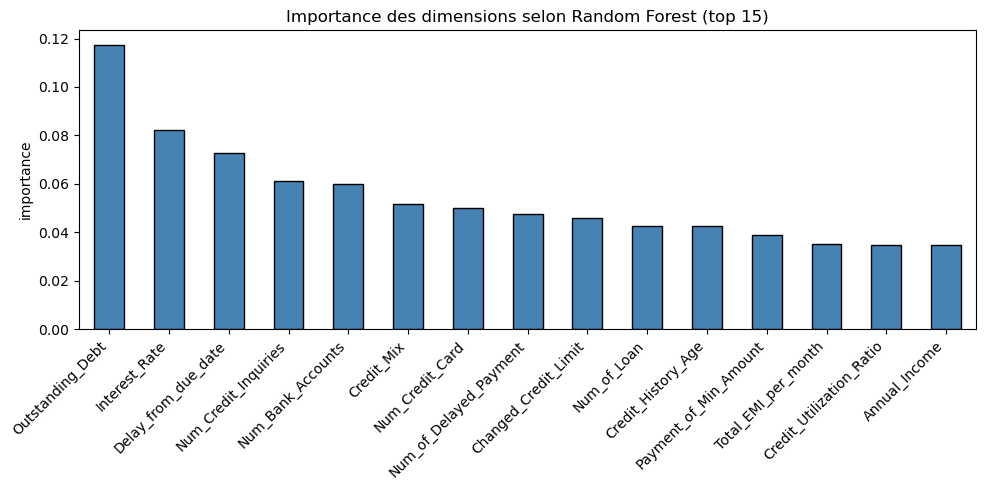

In [21]:
# graphique importance des dimensions
rf_temp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_temp.fit(X_train_res, y_train_res)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_res.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top15.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Importance des dimensions selon Random Forest (top 15)')
plt.ylabel('importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# données avec seulement les features sélectionnées
X_train_sel = X_train_res[cols_sel]
X_test_sel  = X_test[cols_sel]
print(f'shape après sélection : train={X_train_sel.shape} | test={X_test_sel.shape}')

shape après sélection : train=(127617, 9) | test=(20000, 9)


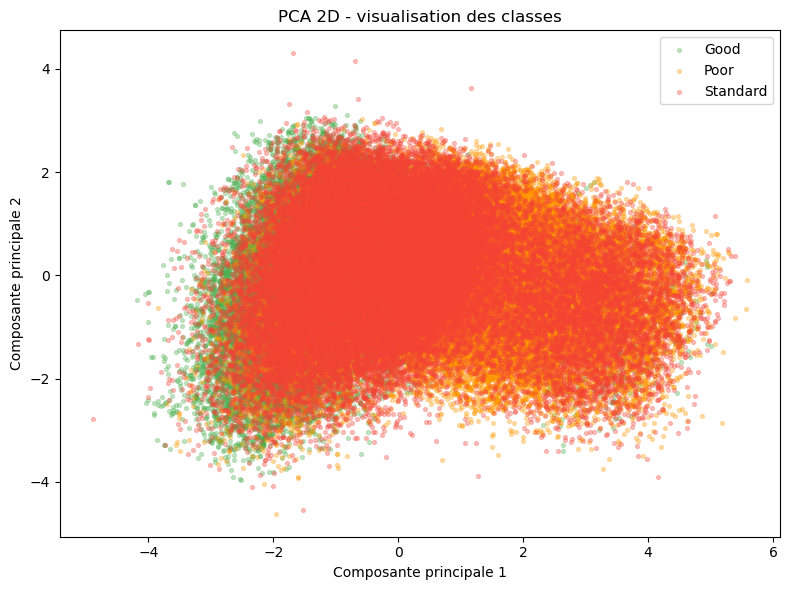

variance expliquée PC1+PC2 : 17.6%


In [23]:
# PCA : StandardScaler avant PCA
# fit uniquement sur le train, transform sur train et test

sc_pca = StandardScaler()
X_train_std = sc_pca.fit_transform(X_train_res)
X_test_std  = sc_pca.transform(X_test)

# visualisation 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_visu = pca_2d.fit_transform(X_train_std)

plt.figure(figsize=(8, 6))
colors_map = ['#4caf50', '#ff9800', '#f44336']
for i, cls in enumerate(le_target.classes_):
    mask = y_train_res == i
    plt.scatter(X_visu[mask, 0], X_visu[mask, 1],
                label=cls, alpha=0.3, s=8, color=colors_map[i])
plt.title('PCA 2D - visualisation des classes')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.tight_layout()
plt.show()
print(f'variance expliquée PC1+PC2 : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

composantes nécessaires pour 95% de variance expliquée : 20


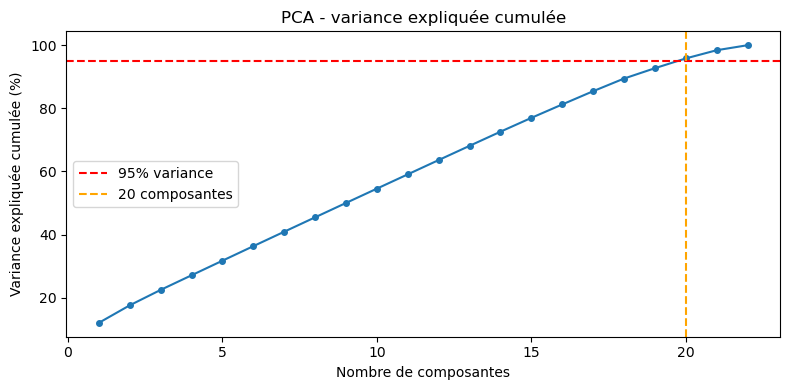

In [24]:
# courbe variance expliquée cumulée -> choisir le bon nombre de composantes
n_max = min(X_train_std.shape[1], 25)
pca_full = PCA(n_components=n_max, random_state=RANDOM_STATE).fit(X_train_std)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f'composantes nécessaires pour 95% de variance expliquée : {n_95}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumsum)+1), cumsum * 100, marker='o', markersize=4)
plt.axhline(95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} composantes')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('PCA - variance expliquée cumulée')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# application de la PCA avec n_95 composantes (pour le SVM)
pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)
print(f'après PCA : train={X_train_pca.shape} | test={X_test_pca.shape}')

après PCA : train=(127617, 20) | test=(20000, 20)


## 5. Modèles de classification

- **Random Forest** : vote majoritaire sur 100 arbres
- **LinearSVC** : SVM linéaire, O(n) → adapté aux 100k lignes
- **Gradient Boosting** : arbres séquentiels (HistGBM)

Validation : K-Fold stratifié k=5

In [26]:
def evaluer_modele(nom, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    # validation croisée k-fold stratifiée
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1_weighted')

    print(f'\n=== {nom} ===')
    print(f'  accuracy    : {acc:.4f}')
    print(f'  f1 weighted : {f1:.4f}')
    print(f'  précision   : {prec:.4f} | rappel : {rec:.4f}')
    print(f'  CV k-fold (k=5) : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

    return model, y_pred, {
        'nom': nom, 'accuracy': acc, 'f1': f1,
        'precision': prec, 'recall': rec,
        'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std()
    }

resultats = []
modeles_dict = {}
preds_dict   = {}

### Random Forest

Features sélectionnées. Pas besoin de normalisation (seuils, pas distances).

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

rf_model, rf_pred, rf_res = evaluer_modele(
    'Random Forest', rf,
    X_train_sel, y_train_res,
    X_test_sel, y_test
)
resultats.append(rf_res)
modeles_dict['Random Forest'] = rf_model
preds_dict['Random Forest']   = rf_pred


=== Random Forest ===
  accuracy    : 0.7693
  f1 weighted : 0.7698
  précision   : 0.7708 | rappel : 0.7693
  CV k-fold (k=5) : 0.8248 +/- 0.0028


### SVM - LinearSVC

On utilise LinearSVC avec noyau linéaire à la place de SVC RBF.  
beaucoup plus rapide sur grands datasets.
CalibratedClassifierCV ajoute les probabilités en sortie.

In [28]:
# LinearSVC + calibration pour avoir les probabilités
lsvc = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=2000)
svm  = CalibratedClassifierCV(lsvc, cv=3)

svm_model, svm_pred, svm_res = evaluer_modele(
    'SVM (LinearSVC)', svm,
    X_train_pca, y_train_res,  # données après PCA + standardisation
    X_test_pca, y_test
)
resultats.append(svm_res)
modeles_dict['SVM (LinearSVC)'] = svm_model
preds_dict['SVM (LinearSVC)']   = svm_pred


=== SVM (LinearSVC) ===
  accuracy    : 0.5319
  f1 weighted : 0.5297
  précision   : 0.6220 | rappel : 0.5319
  CV k-fold (k=5) : 0.6004 +/- 0.0023


### Gradient Boosting

Arbres séquentiels, chaque arbre corrige les erreurs du précédent. learning_rate=0.1 limite le surapprentissage.

In [29]:
gb = HistGradientBoostingClassifier(
    max_iter=100,        # equivalent de n_estimators
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_model, gb_pred, gb_res = evaluer_modele(
    'Gradient Boosting', gb,
    X_train_sel, y_train_res,
    X_test_sel, y_test
)
resultats.append(gb_res)
modeles_dict['Gradient Boosting'] = gb_model
preds_dict['Gradient Boosting']   = gb_pred


=== Gradient Boosting ===
  accuracy    : 0.6933
  f1 weighted : 0.6956
  précision   : 0.7010 | rappel : 0.6933
  CV k-fold (k=5) : 0.7648 +/- 0.0023


## 6. Évaluation des modèles

Métriques : accuracy, précision, rappel, F1 weighted, matrices de confusion.  
On privilégie le F1 weighted (classes déséquilibrées).

In [30]:
# tableau comparatif
df_res = pd.DataFrame(resultats).set_index('nom').round(4)
print('Comparaison des 3 modèles :')
df_res

Comparaison des 3 modèles :


,accuracy,f1,precision,recall,cv_f1_mean,cv_f1_std
nom,,,,,,
Random Forest,0.7693,0.7698,0.7708,0.7693,0.8248,0.0028
SVM (LinearSVC),0.5319,0.5297,0.6220,0.5319,0.6004,0.0023
Gradient Boosting,0.6933,0.6956,0.7010,0.6933,0.7648,0.0023


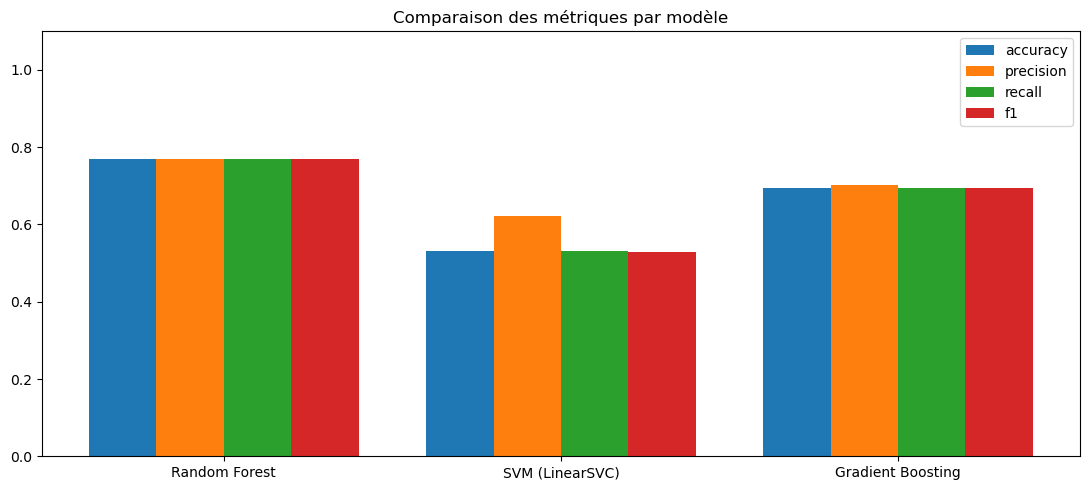

In [31]:
# graphique comparatif métriques
metriques = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(df_res))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
for i, m in enumerate(metriques):
    ax.bar(x + i*width, df_res[m], width, label=m)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(df_res.index)
ax.set_ylim(0, 1.1)
ax.set_title('Comparaison des métriques par modèle')
ax.legend()
plt.tight_layout()
plt.show()

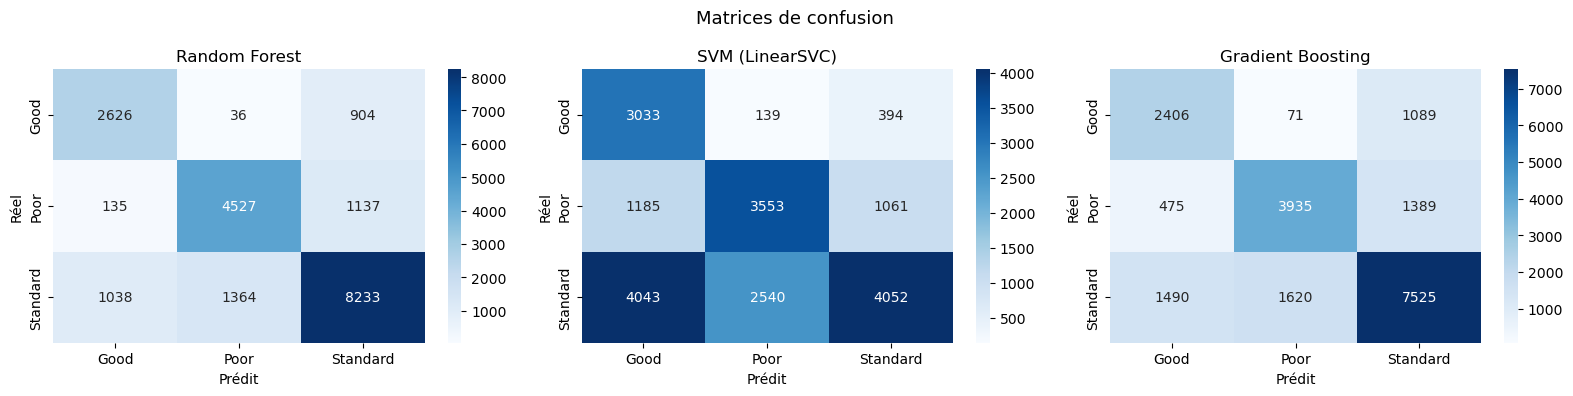

In [32]:
# matrices de confusion pour les 3 modèles
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nom, y_pred) in zip(axes, preds_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=le_target.classes_,
        yticklabels=le_target.classes_,
        cmap='Blues'
    )
    ax.set_title(nom)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
# rapport détaillé du meilleur modèle
meilleur = df_res['f1'].idxmax()
print(f'Meilleur modèle (F1 weighted) : {meilleur}\n')
print(classification_report(
    y_test, preds_dict[meilleur],
    target_names=le_target.classes_
))

Meilleur modèle (F1 weighted) : Random Forest

              precision    recall  f1-score   support

        Good       0.69      0.74      0.71      3566
        Poor       0.76      0.78      0.77      5799
    Standard       0.80      0.77      0.79     10635

    accuracy                           0.77     20000
   macro avg       0.75      0.76      0.76     20000
weighted avg       0.77      0.77      0.77     20000



## 7. Sauvegarde des modèles et transformateurs

Tous les transformateurs et modèles sont sauvegardés en .pkl pour l'interface Streamlit.

In [34]:
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# transformateurs
joblib.dump(scaler,              'models/scaler.pkl')
joblib.dump(imputer,             'models/imputer.pkl')
joblib.dump(encoders,            'models/encoders_cat.pkl')
joblib.dump(le_target,           'models/le_target.pkl')
joblib.dump(sc_pca,              'models/sc_pca.pkl')
joblib.dump(pca,                 'models/pca.pkl')
joblib.dump(cols_sel,            'models/cols_sel.pkl')
joblib.dump(list(X.columns),     'models/feature_cols.pkl')

# modèles
joblib.dump(rf_model,            'models/random_forest.pkl')
joblib.dump(svm_model,           'models/svm.pkl')
joblib.dump(gb_model,            'models/gradient_boosting.pkl')

# résultats
df_res.to_csv('data/resultats_modeles.csv')

print('tout sauvegardé dans models/ et data/')

tout sauvegardé dans models/ et data/


## Bilan

- Préparation des données : nettoyage regex, imputation, normalisation, SMOTE
- Réduction de dimension : Feature Selection + PCA avec StandardScaler
- 3 modèles : Random Forest, SVM (LinearSVC), Gradient Boosting
- Évaluation : accuracy, F1 weighted, précision, rappel, matrices de confusion, K-Fold k=5
- Interface Streamlit : faire `streamlit run app/app.py`